# Fraud Detection EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## Data loading

In [2]:
df = pd.read_csv('../data/retail_fraud_detection_100k.csv')

In [3]:
print('Data shape:')
print('Columns: {}, Rows: {}'.format(df.shape[0], df.shape[1]))

Data shape:
Columns: 100000, Rows: 21


In [4]:
df.head()

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,avg_transaction_amount_7d,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk
0,T0000001,C20953,2026-03-04 19:56:23.679173,56.31,Debit Card,Tablet,Canada,Fashion,0,13,53.02,4,1054,0,0,0,1,0,1,0,Medium
1,T0000002,C24133,2026-03-09 19:56:23.679330,20.35,Credit Card,Tablet,India,Electronics,0,3,38.00,2,97,0,0,0,0,0,0,0,Low
2,T0000003,C07165,2026-01-01 19:56:23.679362,48.72,Debit Card,Tablet,UK,Travel,0,8,147.45,4,779,1,0,0,0,0,0,0,Medium
3,T0000004,C19310,2025-12-09 19:56:23.679385,153.62,Debit Card,Mobile,Australia,Fashion,0,14,58.22,3,286,1,1,0,1,0,1,1,High
4,T0000005,C25019,2025-11-09 19:56:23.679409,115.32,PayPal,Mobile,India,Gaming,0,10,114.46,3,866,0,0,0,1,0,0,0,Low


In [5]:
print(df.dtypes)

transaction_id                       object
customer_id                          object
transaction_timestamp                object
transaction_amount                  float64
payment_method                       object
device_type                          object
location                             object
merchant_category                    object
is_international                      int64
transaction_frequency_24h             int64
avg_transaction_amount_7d           float64
failed_transaction_count_24h          int64
account_age_days                      int64
previous_fraud_flag                   int64
unusual_amount_flag                   int64
unusual_location_flag                 int64
multiple_transactions_short_time      int64
high_risk_device_flag                 int64
velocity_flag                         int64
fraud_flag                            int64
fraud_risk                           object
dtype: object


In [6]:
print('Count unique customers: ')
df['customer_id'].unique().size

Count unique customers: 


28955

In [7]:
df = df.sort_values(by=['transaction_timestamp'])

In [8]:
df.head()

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,avg_transaction_amount_7d,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk
428,T0000429,C18117,2025-04-30 19:56:23.688247,209.35,PayPal,Mobile,Canada,Groceries,1,14,100.50,3,1499,0,1,1,1,0,1,1,High
801,T0000802,C12701,2025-04-30 19:56:23.696115,330.37,Google Pay,Mobile,Canada,Electronics,0,9,101.05,0,1683,0,1,0,1,0,0,0,Low
1021,T0001022,C16921,2025-04-30 19:56:23.700517,140.70,PayPal,Tablet,Australia,Travel,0,14,38.04,0,1058,1,1,0,1,0,1,1,Medium
1055,T0001056,C22487,2025-04-30 19:56:23.701177,0.65,PayPal,Desktop,Germany,Travel,0,6,97.23,3,1826,0,0,0,0,0,0,0,Low
1216,T0001217,C07940,2025-04-30 19:56:23.704498,230.28,Debit Card,Mobile,India,Electronics,1,1,44.73,1,512,1,1,1,0,1,0,1,High


## Data cleaning

In [9]:
print('Missing values: ')
print(df.isnull().sum())

Missing values: 
transaction_id                      0
customer_id                         0
transaction_timestamp               0
transaction_amount                  0
payment_method                      0
device_type                         0
location                            0
merchant_category                   0
is_international                    0
transaction_frequency_24h           0
avg_transaction_amount_7d           0
failed_transaction_count_24h        0
account_age_days                    0
previous_fraud_flag                 0
unusual_amount_flag                 0
unusual_location_flag               0
multiple_transactions_short_time    0
high_risk_device_flag               0
velocity_flag                       0
fraud_flag                          0
fraud_risk                          0
dtype: int64


In [10]:
print('Contains duplicates?')
print(df.duplicated().any())

Contains duplicates?
False


In [11]:
print('Any transactions less than 0?')
print((df['transaction_amount'] < 0).any())

Any transactions less than 0?
False


In [12]:
print('Unique payment methods')
print(df['payment_method'].unique())

Unique payment methods
['PayPal' 'Google Pay' 'Debit Card' 'Apple Pay' 'Credit Card']


## Exploratory Data Analysis

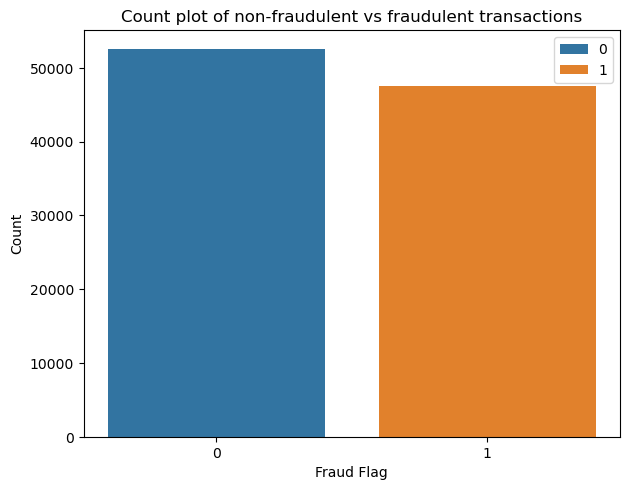

Fraudulent transactions: 47.51%


In [13]:
ax = sns.countplot(data=df, x='fraud_flag', hue='fraud_flag', dodge=False)
ax.legend(loc='upper right')
ax.margins(x=0.05)
plt.xlabel('Fraud Flag')
plt.ylabel('Count')
plt.tight_layout()
plt.title('Count plot of non-fraudulent vs fraudulent transactions')
plt.show()

fraud_count = (df['fraud_flag'] == 1).sum()
non_fraud_count = (df['fraud_flag'] == 0).sum()

print('Fraudulent transactions: {:.2f}%'.format((fraud_count/(fraud_count + non_fraud_count)) * 100))

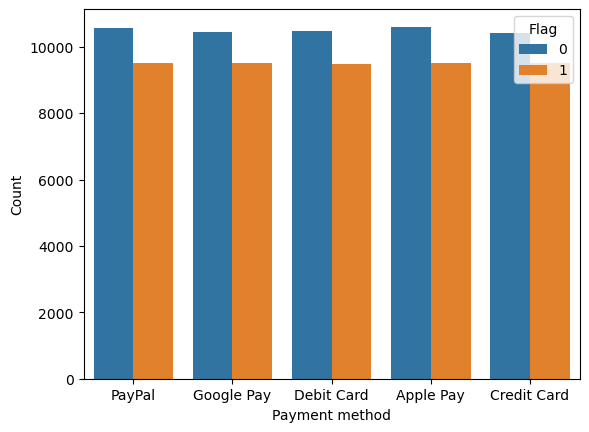

Each payment method carries very similar risks


In [14]:
ax = sns.countplot(data=df, x='payment_method', hue='fraud_flag')
plt.xlabel('Payment method')
plt.ylabel('Count')
plt.legend(title='Flag')
plt.show()

print('Each payment method carries very similar risks')

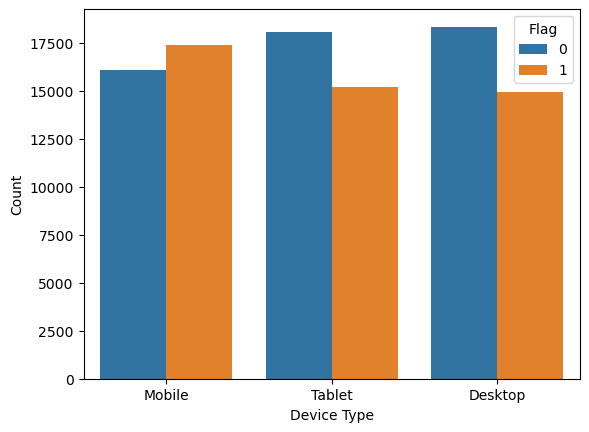

Fraudulent mobile transactions: 51.93%
Fraudulent tablet transactions: 45.65%
Fraudulent desktop transactions: 44.92%


In [15]:
ax = sns.countplot(data=df, x='device_type', hue='fraud_flag')
plt.xlabel('Device Type')
plt.ylabel('Count')
plt.legend(title='Flag')
plt.show()

mobile_fraud_count = (((df['device_type'] == 'Mobile') & (df['fraud_flag'] == 1))).sum()
mobile_non_fraud_count = (((df['device_type'] == 'Mobile') & (df['fraud_flag'] == 0))).sum()

tablet_fraud_count = (((df['device_type'] == 'Tablet') & (df['fraud_flag'] == 1))).sum()
tablet_non_fraud_count = (((df['device_type'] == 'Tablet') & (df['fraud_flag'] == 0))).sum()

desktop_fraud_count = (((df['device_type'] == 'Desktop') & (df['fraud_flag'] == 1))).sum()
desktop_non_fraud_count = (((df['device_type'] == 'Desktop') & (df['fraud_flag'] == 0))).sum()

print('Fraudulent mobile transactions: {:.2f}%'.format(mobile_fraud_count / (mobile_fraud_count + mobile_non_fraud_count) * 100))
print('Fraudulent tablet transactions: {:.2f}%'.format(tablet_fraud_count / (tablet_fraud_count + tablet_non_fraud_count) * 100))
print('Fraudulent desktop transactions: {:.2f}%'.format(desktop_fraud_count / (desktop_fraud_count + desktop_non_fraud_count) * 100))

TP TN
TN TP


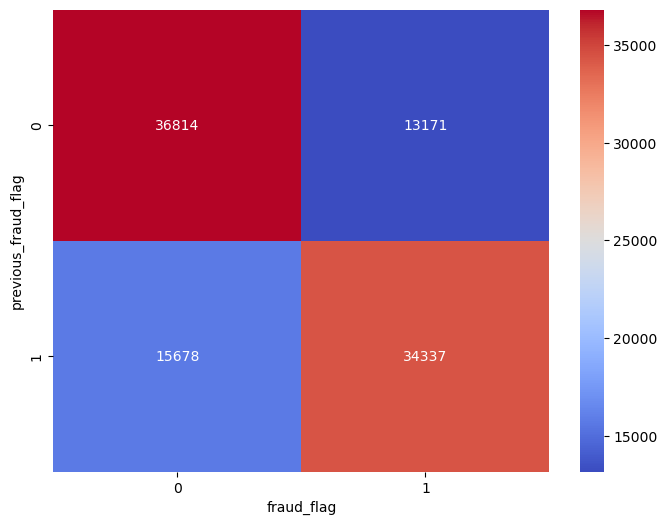

In [16]:
matrix_data = pd.crosstab(df['previous_fraud_flag'], df['fraud_flag'])

plt.figure(figsize=(8, 6))
sns.heatmap(data=matrix_data, annot=True, fmt='d', cmap='coolwarm', cbar=True)

print('TP', 'TN')
print('TN', 'TP')

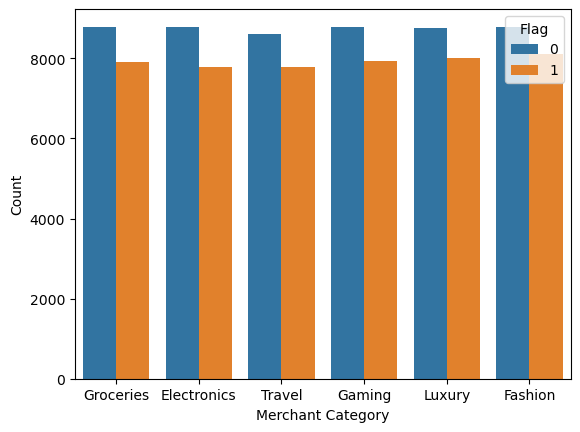

Fraudulent merchant categories are very similar


In [17]:
ax = sns.countplot(data=df, x='merchant_category', hue='fraud_flag')
plt.xlabel('Merchant Category')
plt.ylabel('Count')
plt.legend(title='Flag')
plt.show()

print('Fraudulent merchant categories are very similar')

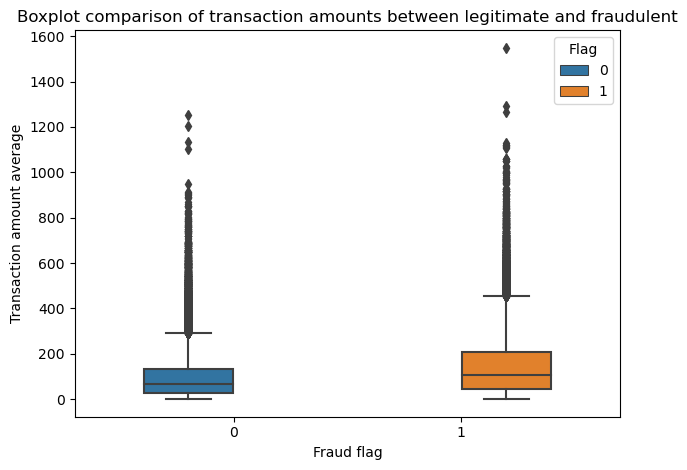

Higher median on the fraudulent transactions


In [18]:
ax = sns.boxplot(data=df, x='fraud_flag', y='transaction_amount', hue='fraud_flag')
ax.legend(loc='upper right')
ax.margins(x=0.05)
plt.title('Boxplot comparison of transaction amounts between legitimate and fraudulent')
plt.xlabel('Fraud flag')
plt.ylabel('Transaction amount average')
plt.legend(title='Flag')
plt.tight_layout()
plt.show()

print('Higher median on the fraudulent transactions')

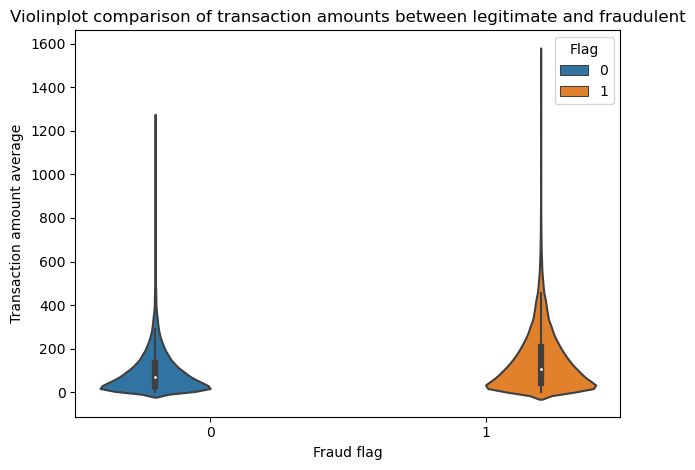

Spread of data points is similar, and fraudulent outliers are higher than the legitimate transactions


In [19]:
ax = sns.violinplot(data=df, x='fraud_flag', y='transaction_amount', hue='fraud_flag')
ax.legend(loc='upper right')
ax.margins(x=0.05)
plt.title('Violinplot comparison of transaction amounts between legitimate and fraudulent')
plt.xlabel('Fraud flag')
plt.ylabel('Transaction amount average')
plt.legend(title='Flag')
plt.tight_layout()
plt.show()

print('Spread of data points is similar, and fraudulent outliers are higher than the legitimate transactions')

In [20]:
correlation = df['multiple_transactions_short_time'].corr(df['fraud_flag'])

print('R score: ', correlation)

R score:  0.34836441091990633


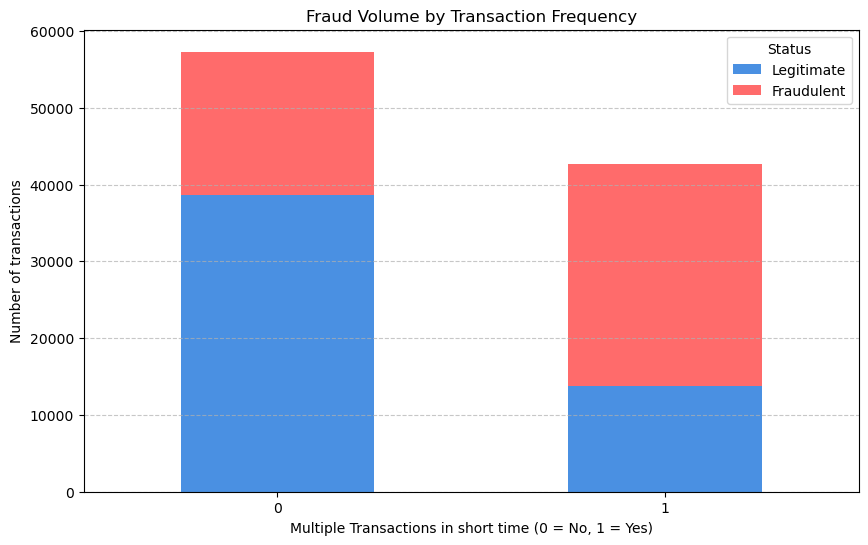

In [21]:
ct = pd.crosstab(df['multiple_transactions_short_time'], df['fraud_flag'])

ax = ct.plot(kind='bar', stacked=True, figsize=(10,6), color=['#4A90E2', '#FF6B6B'])

plt.title('Fraud Volume by Transaction Frequency')
plt.xlabel('Multiple Transactions in short time (0 = No, 1 = Yes)')
plt.ylabel('Number of transactions')
plt.xticks(rotation=0)
plt.legend(['Legitimate', 'Fraudulent'], title='Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

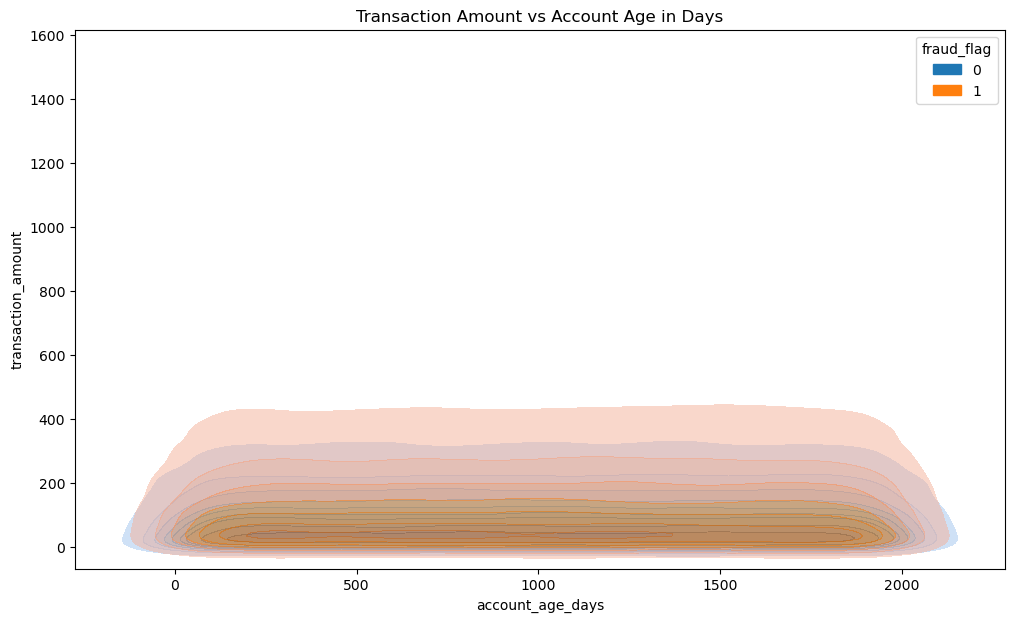

In [22]:
plt.figure(figsize=(12, 7))
sns.kdeplot(data=df, x='account_age_days', y='transaction_amount', hue='fraud_flag', fill=True, alpha=0.5)
plt.title('Transaction Amount vs Account Age in Days')
plt.show()

In [23]:
# Account age is likely a weak predictor despite testing with both scatterplot and contour plot

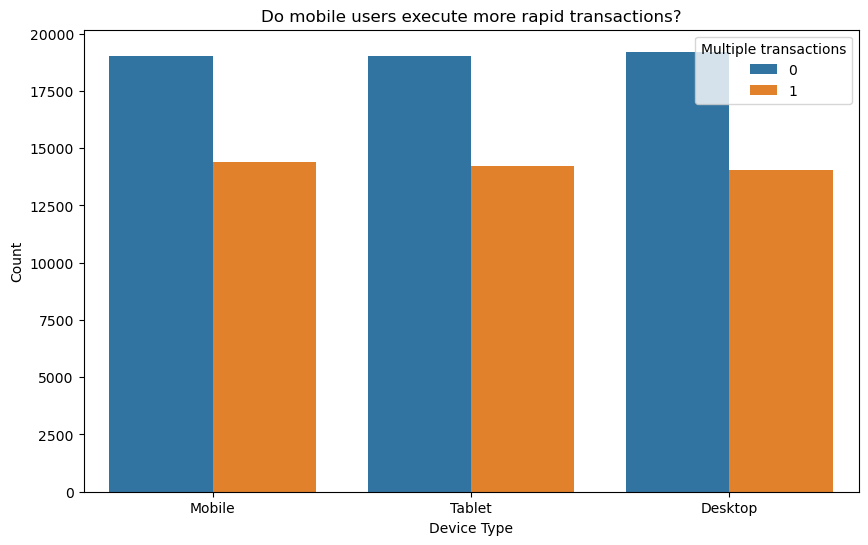

In [24]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='device_type', hue='multiple_transactions_short_time')
plt.xlabel('Device Type')
plt.ylabel('Count')
plt.legend(title='Multiple transactions')
plt.title('Do mobile users execute more rapid transactions?')
plt.show()

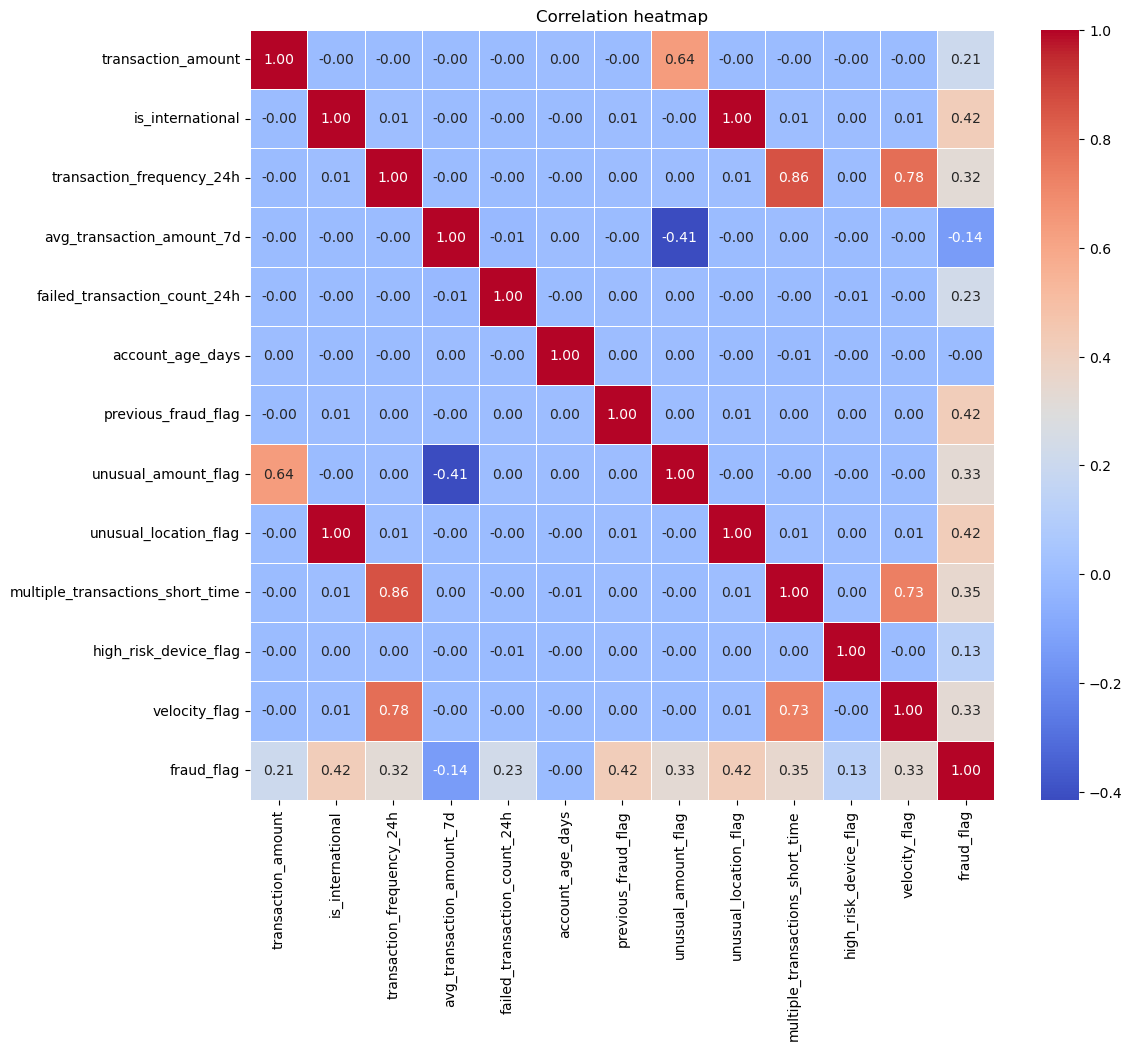

In [25]:
plt.figure(figsize=(12, 10))
corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidth=0.5)
plt.title('Correlation heatmap')
plt.show()

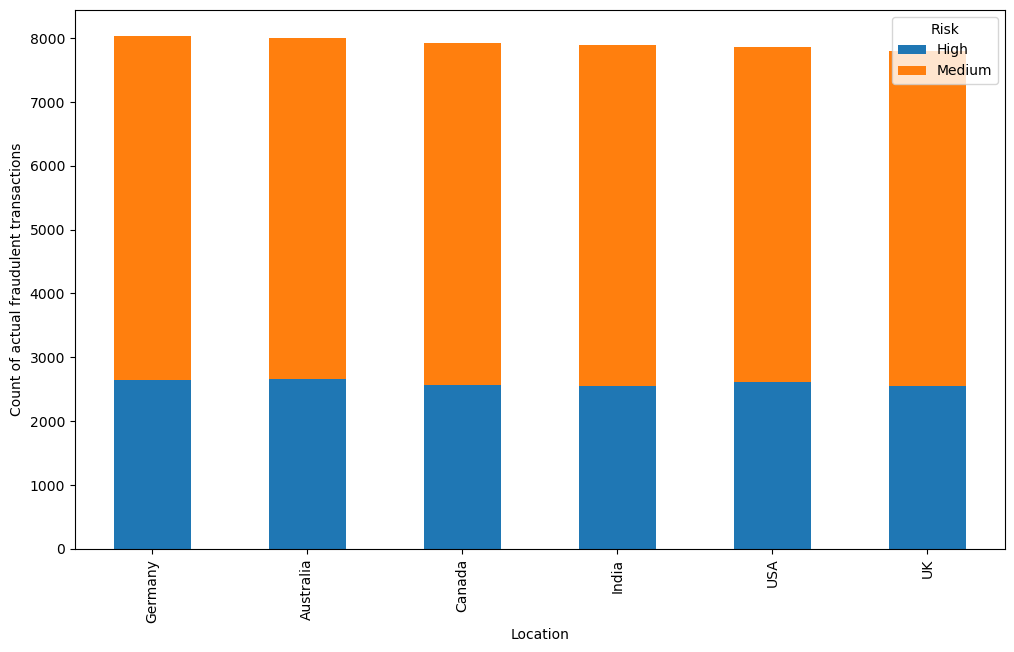

In [26]:
fraud_cases = df[df['fraud_flag'] == 1]
# Low risk would be already filtered out with this

location_risk_gap = fraud_cases.groupby(['location', 'fraud_risk']).size().unstack(fill_value=0)

top_locations = location_risk_gap.sum(axis=1).sort_values(ascending=False).index

location_risk_gap = location_risk_gap.loc[top_locations]

location_risk_gap.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.ylabel('Count of actual fraudulent transactions')
plt.xlabel('Location')
plt.legend(title='Risk', loc='upper right')
plt.show()

In [27]:
correlations = df.select_dtypes(include=['number']).corr()['fraud_flag'].sort_values(ascending=False)

corr_df = correlations.to_frame().reset_index()
corr_df.columns = ['Feature', 'Correlation_with_fraud']

corr_df = corr_df[corr_df['Feature'] != 'fraud_flag']

print('Top predictors for fraud')
print(corr_df)

Top predictors for fraud
                             Feature  Correlation_with_fraud
1                previous_fraud_flag                0.423561
2                   is_international                0.422911
3              unusual_location_flag                0.422911
4   multiple_transactions_short_time                0.348364
5                unusual_amount_flag                0.329398
6                      velocity_flag                0.326297
7          transaction_frequency_24h                0.324047
8       failed_transaction_count_24h                0.228550
9                 transaction_amount                0.206105
10             high_risk_device_flag                0.126393
11                  account_age_days               -0.002136
12         avg_transaction_amount_7d               -0.138906


In [28]:
df_encoded = df.copy()

risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df_encoded['fraud_risk'] = df_encoded['fraud_risk'].map(risk_mapping)

categorical_cols = ['payment_method', 'device_type', 'location', 'merchant_category']
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols)
df_encoded = df_encoded.drop(columns=['transaction_id', 'customer_id', 'transaction_timestamp'], errors='ignore')

full_corr = df_encoded.corr()['fraud_flag'].sort_values(ascending=False)

print('Predictors (including categorical) for fraud')
print(full_corr)

Predictors (including categorical) for fraud
fraud_flag                          1.000000
fraud_risk                          0.700705
previous_fraud_flag                 0.423561
is_international                    0.422911
unusual_location_flag               0.422911
multiple_transactions_short_time    0.348364
unusual_amount_flag                 0.329398
velocity_flag                       0.326297
transaction_frequency_24h           0.324047
failed_transaction_count_24h        0.228550
transaction_amount                  0.206105
high_risk_device_flag               0.126393
device_type_Mobile                  0.062799
merchant_category_Fashion           0.004247
location_Germany                    0.004135
location_Australia                  0.003619
payment_method_Credit Card          0.002203
merchant_category_Luxury            0.001932
payment_method_Google Pay           0.001287
payment_method_Debit Card           0.000371
location_India                     -0.000228
merchant_c